# Overseer-Cleanup: Experiment 1 & 2 Analysis

- **Experiment 1 — Main condition comparison.** `random` vs `fixed_rule` vs `adaptive` vs
  `targeted`, at matched audit budget: learning curves + convergence values for
  `true_completion_rate`, `cheat_rate`, `report_rate`, `audit_prob`.
- **Experiment 2 — Arms-race dynamics.** For `adaptive` only: does `audit_prob` track
  `cheat_rate` over training, or does it just climb to `MAX_AUDIT_PROB` and sit there?

Point the four paths below at your downloaded monitor logs, one file per condition.


## Setup

In [1]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


In [14]:

# ---- Edit these to point at your files ----
MONITOR_FILES = {
    "random":     '../results/logs/random_seed5/monitor.csv',
    "fixed_rule": '../results/logs/fixed_rule_seed5/monitor.csv',
    "adaptive":   '../results/logs/adaptive_seed5/monitor.csv',
    "targeted":   '../results/logs/targeted_seed5/monitor.csv',
}

POSITION_FILES = {
    "random":     "../results/position_log_random_seed5.csv",
    "fixed_rule": "../results/position_log_fixed_rule_seed5.csv",
    "adaptive":   "../results/position_log_adaptive_seed5.csv",
    "targeted":   "../results/position_log_targeted_seed5.csv",
}

COLORS = {"random": "#FF69B4", "fixed_rule": "#1f77b4", "adaptive": "#d62728", "targeted": "#2ca02c"}
METRICS = ["true_completion_rate", "cheat_rate", "report_rate", "audit_prob"]
ROLLING_WINDOW = 50          # episodes, for learning-curve smoothing
CONVERGENCE_FRAC = 0.10      # last 10% of episodes = "converged" value
GRID_N = 8                   # env grid size


## Load the monitor logs

In [15]:

def load_monitor(path, condition):
    df = pd.read_csv(path, skiprows=1)  # skip the SB3 Monitor '#{...}' header line
    df["condition"] = condition
    df["episode"] = np.arange(1, len(df) + 1)
    return df

monitor_df = pd.concat(
    [load_monitor(p, c) for c, p in MONITOR_FILES.items()], ignore_index=True
)
monitor_df["episode_smooth"] = monitor_df.groupby("condition")["episode"].transform(lambda s: s)
for m in METRICS:
    monitor_df[f"{m}_smooth"] = (
        monitor_df.groupby("condition")[m]
                  .transform(lambda s: s.rolling(ROLLING_WINDOW, min_periods=1).mean())
    )

monitor_df.groupby("condition")[METRICS].describe().T


condition                      adaptive    fixed_rule        random  \
true_completion_rate count  4000.000000  4.000000e+03  4.000000e+03   
                     mean      0.736223  7.841582e-01  2.293726e-01   
                     std       0.411912  3.533585e-01  1.597763e-01   
                     min       0.000000  0.000000e+00  0.000000e+00   
                     25%       0.250000  7.202381e-01  1.000000e-01   
                     50%       1.000000  1.000000e+00  2.142857e-01   
                     75%       1.000000  1.000000e+00  3.333333e-01   
                     max       1.000000  1.000000e+00  1.000000e+00   
cheat_rate           count  4000.000000  4.000000e+03  4.000000e+03   
                     mean      0.017134  1.056212e-02  7.433295e-01   
                     std       0.105932  8.960594e-02  2.361451e-01   
                     min       0.000000  0.000000e+00  0.000000e+00   
                     25%       0.000000  0.000000e+00  6.666667e-01   
                     50%       0.000000  0.000000e+00  8.000000e-01   
                     75%       0.000000  0.000000e+00  9.000000e-01   
                     max       1.000000  1.000000e+00  1.000000e+00   
report_rate          count  4000.000000  4.000000e+03  4.000000e+03   
                     mean      0.495471  1.476689e-01  7.464515e-01   
                     std       0.448202  2.554946e-01  3.953099e-01   
                     min       0.000000  0.000000e+00  0.000000e+00   
                     25%       0.000000  0.000000e+00  4.615385e-01   
                     50%       0.428571  0.000000e+00  7.500000e-01   
                     75%       1.000000  2.105263e-01  1.000000e+00   
                     max       1.300000  1.100000e+00  2.600000e+00   
audit_prob           count  4000.000000  4.000000e+03  4.000000e+03   
                     mean      0.212276  4.000000e-01  5.000000e-02   
                     std       0.243128  5.551809e-17  6.939761e-18   
                     min       0.050000  4.000000e-01  5.000000e-02   
                     25%       0.050004  4.000000e-01  5.000000e-02   
                     50%       0.066852  4.000000e-01  5.000000e-02   
                     75%       0.300153  4.000000e-01  5.000000e-02   
                     max       0.900000  4.000000e-01  5.000000e-02   

condition                      targeted  
true_completion_rate count  4000.000000  
                     mean      0.809415  
                     std       0.359176  
                     min       0.000000  
                     25%       0.921474  
                     50%       1.000000  
                     75%       1.000000  
                     max       1.000000  
cheat_rate           count  4000.000000  
                     mean      0.015208  
                     std       0.089824  
                     min       0.000000  
                     25%       0.000000  
                     50%       0.000000  
                     75%       0.000000  
                     max       1.000000  
report_rate          count  4000.000000  
                     mean      0.545478  
                     std       0.441323  
                     min       0.000000  
                     25%       0.000000  
                     50%       0.529412  
                     75%       1.000000  
                     max       1.200000  
audit_prob           count  4000.000000  
                     mean      0.192767  
                     std       0.236858  
                     min       0.050000  
                     25%       0.050116  
                     50%       0.062013  
                     75%       0.233501  
                     max       0.900000

## Experiment 1 — Main condition comparison

Hypothesis: at matched average audit budget, `adaptive` converges to lower `cheat_rate`
and higher `true_completion_rate` than `fixed_rule`, and both beat `random`.


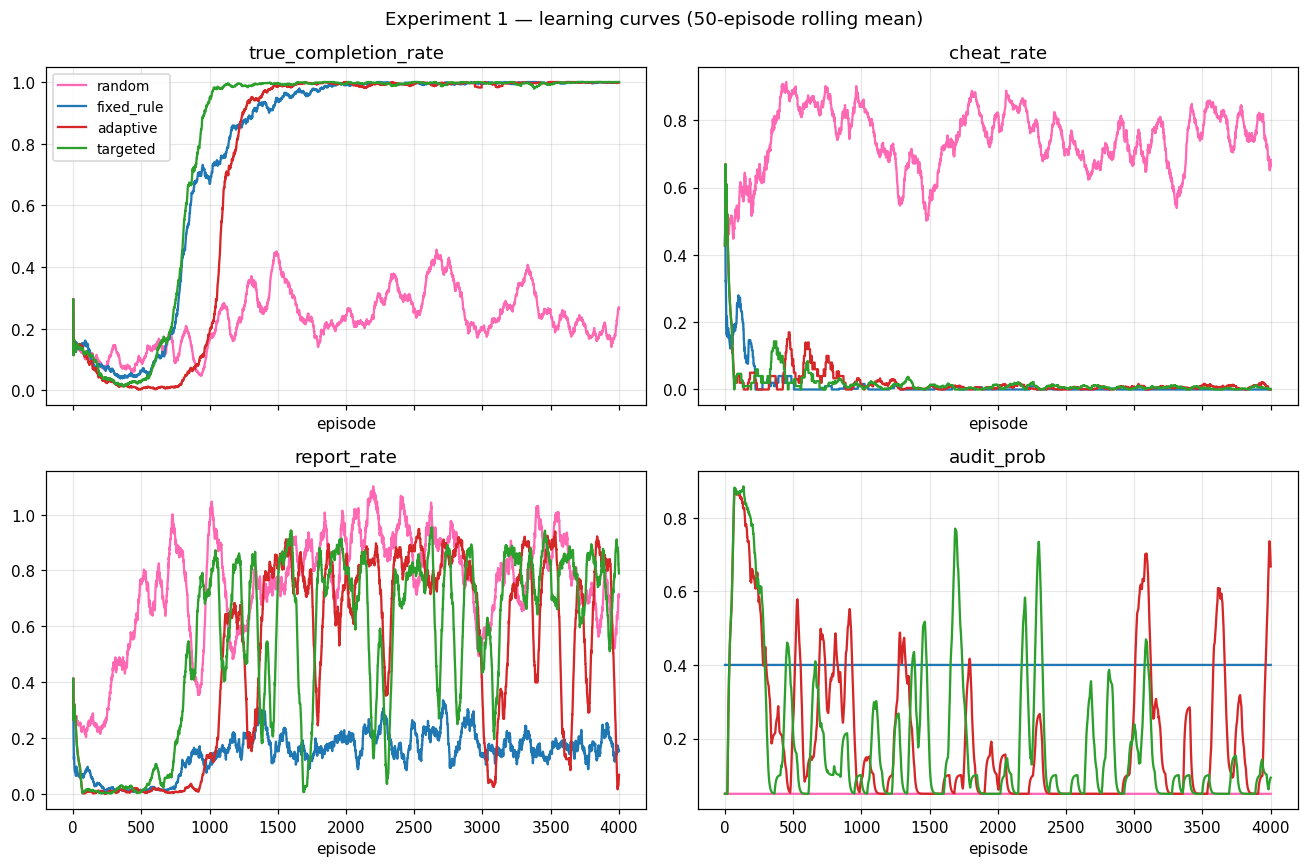

In [16]:

# Learning curves: one smoothed line per condition, per metric
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, metric in zip(axes.flat, METRICS):
    for cond in MONITOR_FILES:
        sub = monitor_df[monitor_df["condition"] == cond]
        ax.plot(sub["episode"], sub[f"{metric}_smooth"], label=cond, color=COLORS[cond])
    ax.set_title(metric)
    ax.set_xlabel("episode")

axes[0, 0].legend(fontsize=9)
fig.suptitle(f"Experiment 1 — learning curves ({ROLLING_WINDOW}-episode rolling mean)")
fig.tight_layout()
plt.show()


In [5]:

# Convergence values: mean over the final CONVERGENCE_FRAC of episodes, per condition
def tail_mean(df, frac=CONVERGENCE_FRAC):
    n_tail = max(1, int(len(df) * frac))
    return df.sort_values("episode").tail(n_tail)[METRICS].mean()

convergence = monitor_df.groupby("condition").apply(tail_mean, include_groups=False)
convergence = convergence.reindex(MONITOR_FILES.keys())
convergence


,true_completion_rate,cheat_rate,report_rate,audit_prob
condition,,,,
random,0.198620,0.765864,0.699223,0.050000
fixed_rule,0.998601,0.000000,0.168224,0.400000
adaptive,0.998769,0.008375,0.550443,0.261439
targeted,0.999750,0.003527,0.763733,0.080989


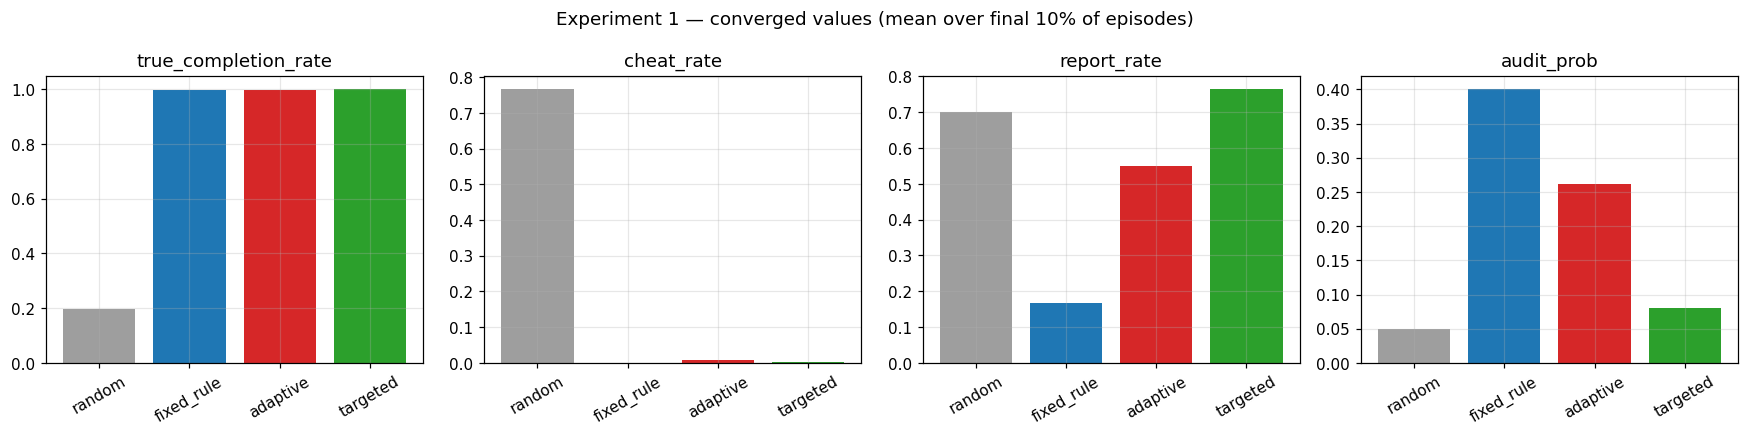

In [6]:

# Convergence bar chart
fig, axes = plt.subplots(1, len(METRICS), figsize=(4 * len(METRICS), 4))
for ax, metric in zip(axes, METRICS):
    ax.bar(convergence.index, convergence[metric], color=[COLORS[c] for c in convergence.index])
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=30)

fig.suptitle(f"Experiment 1 — converged values (mean over final {int(CONVERGENCE_FRAC*100)}% of episodes)")
fig.tight_layout()
plt.show()


**Reading this against the hypothesis:** check that `adaptive`'s `cheat_rate` bar
sits below `fixed_rule`'s while their `audit_prob` bars are comparable (matched budget —
if they're not, the comparison isn't apples-to-apples), and that both sit below `random`.

## Experiment 2 — Arms-race dynamics (`adaptive` only)

Hypothesis: `audit_prob` rises with recent cheating and decays as cheating is suppressed
— rather than climbing to `MAX_AUDIT_PROB` and just sitting there regardless of behavior.


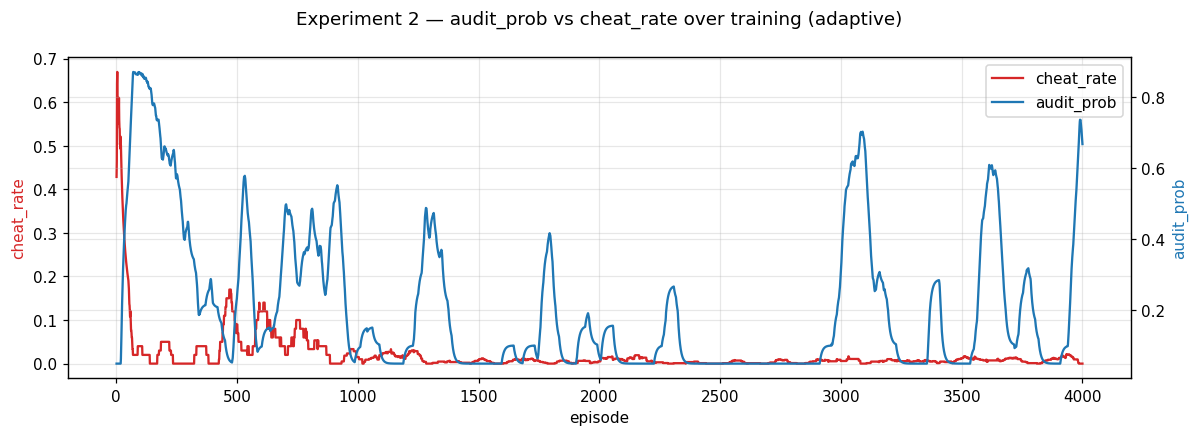

correlation(cheat_rate, audit_prob) = -0.04


In [7]:

adaptive = monitor_df[monitor_df["condition"] == "adaptive"].sort_values("episode")

fig, ax = plt.subplots(figsize=(11, 4))
ax2 = ax.twinx()
l1, = ax.plot(adaptive["episode"], adaptive["cheat_rate_smooth"], color="#d62728", label="cheat_rate")
l2, = ax2.plot(adaptive["episode"], adaptive["audit_prob_smooth"], color="#1f77b4", label="audit_prob")
ax.set_ylabel("cheat_rate", color="#d62728")
ax2.set_ylabel("audit_prob", color="#1f77b4")
ax.set_xlabel("episode")
ax.legend(handles=[l1, l2], loc="upper right")
fig.suptitle("Experiment 2 — audit_prob vs cheat_rate over training (adaptive)")
fig.tight_layout()
plt.show()

corr = adaptive["cheat_rate"].corr(adaptive["audit_prob"])
print(f"correlation(cheat_rate, audit_prob) = {corr:.2f}")


A visibly co-moving pair of curves (audit_prob rising into cheat_rate peaks, falling
as they subside) plus a clearly positive correlation supports the reactive-suspicion
story. A flat `audit_prob` pinned near its cap regardless of `cheat_rate` swings would
instead suggest the mechanism is saturating rather than behavior-contingent — worth
checking directly against the max value `audit_prob` actually reaches in `convergence`
above.

## Position logs — what's interesting there

In [8]:

def load_positions(path, condition):
    df = pd.read_csv(path)
    df["condition"] = condition
    return df

position_df = pd.concat(
    [load_positions(p, c) for c, p in POSITION_FILES.items()], ignore_index=True
)
print(position_df.groupby("condition")["episode"].nunique().rename("n_logged_episodes"))
position_df.head()


condition
adaptive      80
fixed_rule    80
random        80
targeted      80
Name: n_logged_episodes, dtype: int64


,episode,step,x,y,condition
0,50,0,5,4,random
1,50,1,5,4,random
2,50,2,5,4,random
3,50,3,5,3,random
4,50,4,6,3,random


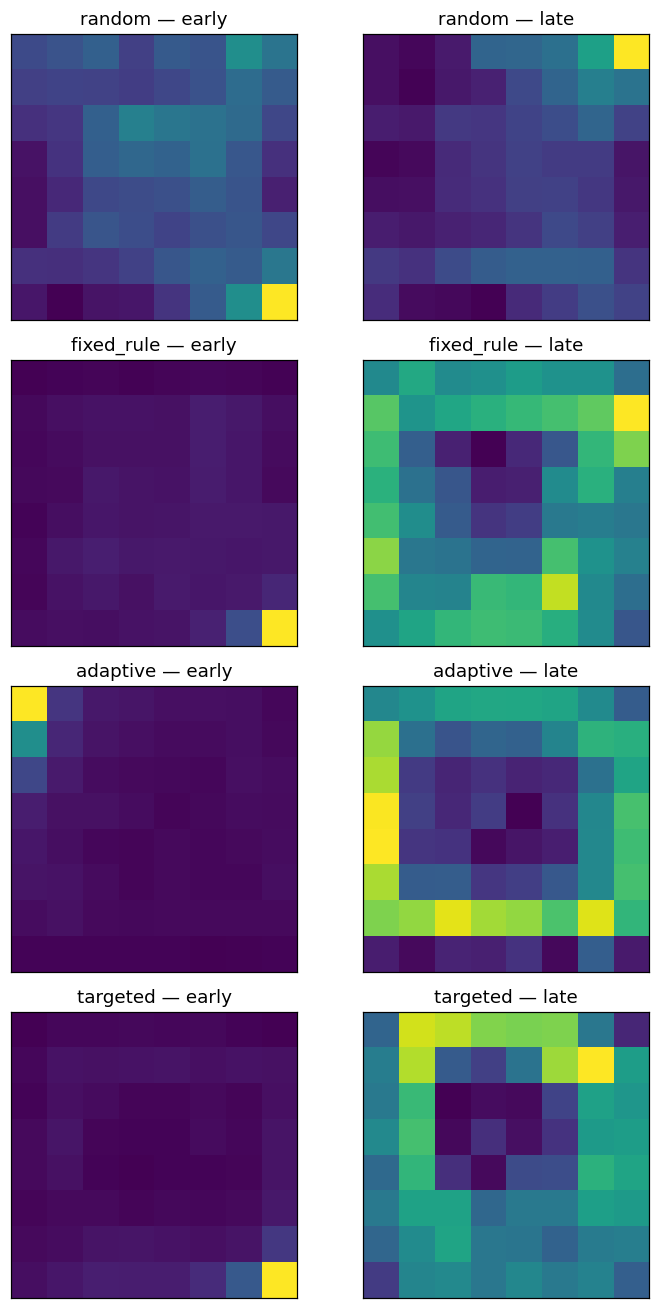

In [9]:

# Visitation heatmap per condition (early vs late in the logged episodes) —
# is the agent roaming to chase dirt, or idling once local dirt is gone?
fig, axes = plt.subplots(len(POSITION_FILES), 2, figsize=(7, 3 * len(POSITION_FILES)))
for row, cond in enumerate(POSITION_FILES):
    sub = position_df[position_df["condition"] == cond]
    eps = sorted(sub["episode"].unique())
    if not eps:
        continue
    half = len(eps) // 2 or 1
    early_eps, late_eps = eps[:half], eps[half:] or eps[:half]

    for col, (label, ep_subset) in enumerate([("early", early_eps), ("late", late_eps)]):
        stage = sub[sub["episode"].isin(ep_subset)]
        grid = np.zeros((GRID_N, GRID_N))
        for x, y in zip(stage["x"], stage["y"]):
            grid[int(y), int(x)] += 1
        ax = axes[row, col]
        ax.imshow(grid, cmap="viridis", origin="lower")
        ax.set_title(f"{cond} — {label}")
        ax.set_xticks([]); ax.set_yticks([])

fig.tight_layout()
plt.show()


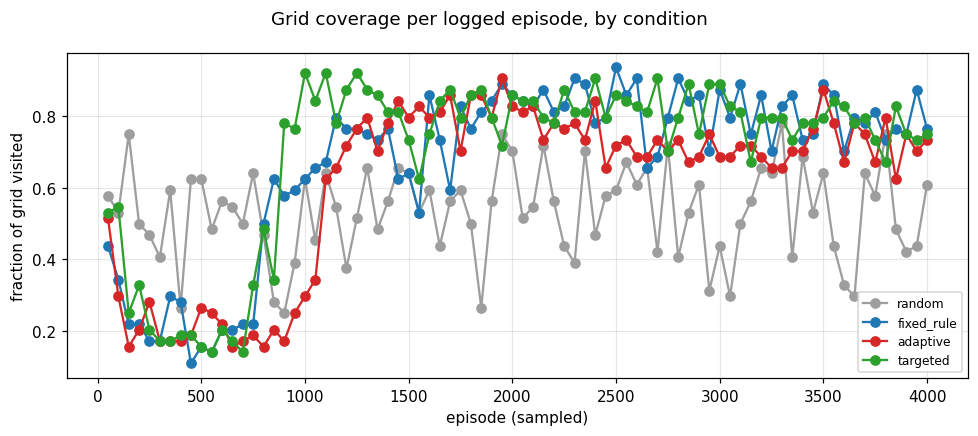

In [10]:

# Coverage: fraction of the grid actually visited per logged episode
def coverage_pct(group, grid_n=GRID_N):
    return len(set(zip(group["x"], group["y"]))) / (grid_n * grid_n)

per_episode_coverage = (
    position_df.groupby(["condition", "episode"])
               .apply(coverage_pct, include_groups=False)
               .rename("coverage_pct")
               .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
for cond in POSITION_FILES:
    sub = per_episode_coverage[per_episode_coverage["condition"] == cond].sort_values("episode")
    ax.plot(sub["episode"], sub["coverage_pct"], marker="o", label=cond, color=COLORS[cond])
ax.set_xlabel("episode (sampled)")
ax.set_ylabel("fraction of grid visited")
ax.legend(fontsize=8)
fig.suptitle("Grid coverage per logged episode, by condition")
fig.tight_layout()
plt.show()
